In [2]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt

import torch

from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN

from transformers import GPT2Tokenizer, GPT2Model

In [3]:
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2Model.from_pretrained('gpt2')

embeddings = model.wte.weight.detach().numpy()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Tokenize emojis

In [4]:
emoji_list = ['💗', '❤️', '💓', '😍', '💖',
              '🔥', '😂', '😢', '💔', '😊']

for emoji in emoji_list:
  print(f'{emoji} is {len(emoji)} "characters" and uses tokens: {tokenizer.encode(emoji)}')

💗 is 1 "characters" and uses tokens: [8582, 240, 245]
❤️ is 2 "characters" and uses tokens: [32391, 97, 37929]
💓 is 1 "characters" and uses tokens: [8582, 240, 241]
😍 is 1 "characters" and uses tokens: [47249, 235]
💖 is 1 "characters" and uses tokens: [8582, 240, 244]
🔥 is 1 "characters" and uses tokens: [8582, 242, 98]
😂 is 1 "characters" and uses tokens: [47249, 224]
😢 is 1 "characters" and uses tokens: [47249, 95]
💔 is 1 "characters" and uses tokens: [8582, 240, 242]
😊 is 1 "characters" and uses tokens: [47249, 232]


In [5]:
for emoji in emoji_list:
  unicode_points = [f'U+{ord(e):04x}' for e in emoji]
  print(f'Unicode for {emoji} is {" ".join(unicode_points)}')


Unicode for 💗 is U+1f497
Unicode for ❤️ is U+2764 U+fe0f
Unicode for 💓 is U+1f493
Unicode for 😍 is U+1f60d
Unicode for 💖 is U+1f496
Unicode for 🔥 is U+1f525
Unicode for 😂 is U+1f602
Unicode for 😢 is U+1f622
Unicode for 💔 is U+1f494
Unicode for 😊 is U+1f60a


# Inspect the emoji embeddings

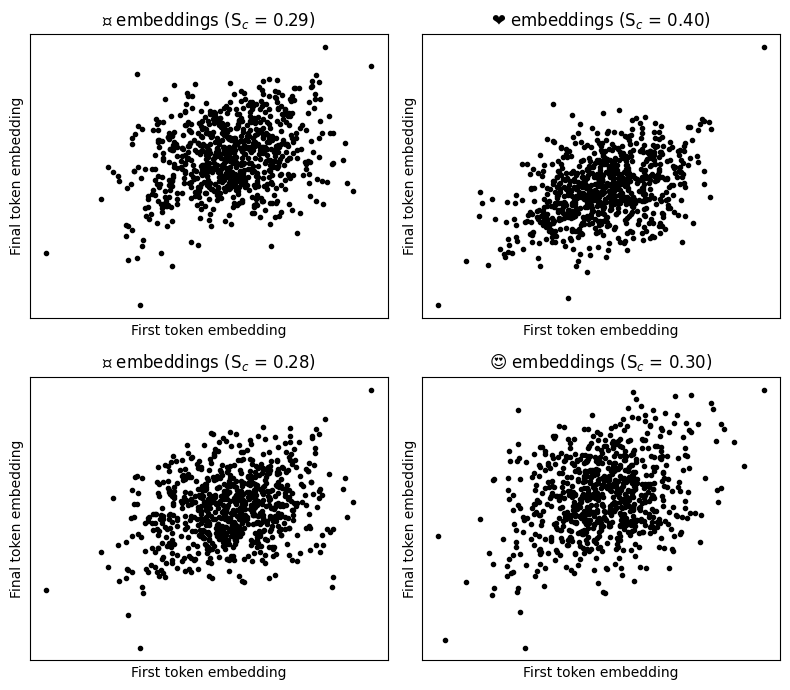

In [6]:
# calculate and visualize intra-emoji embeddings

_,axs = plt.subplots(2,2,figsize=(8,7))

for i,ax in enumerate(axs.flatten()):

  # get the tokens and plt the first by the last vectors
  toks = tokenizer.encode(emoji_list[i])
  ax.plot(embeddings[toks[0]],embeddings[toks[-1]],'k.')

  # cosine similarity
  v1,v2 = embeddings[toks[0]], embeddings[toks[-1]]
  cs = sum(v1*v2) / np.sqrt( sum(v1**2)*sum(v2**2) )

  ax.set(xticks=[],yticks=[],xlabel='First token embedding',ylabel='Final token embedding',
         title=f'{emoji_list[i]} embeddings (S$_c$ = {cs:.2f})')


plt.tight_layout()
plt.show()

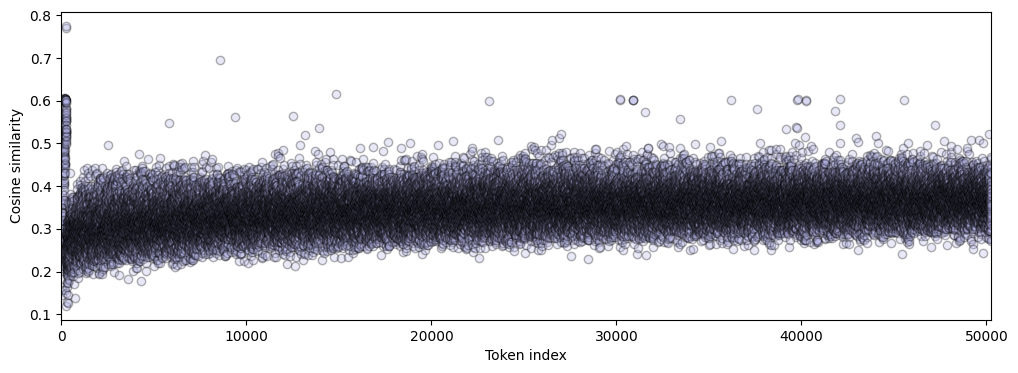

In [7]:
# just the first emoji, averaging the embeddings vectors
toks = tokenizer.encode(emoji_list[0])
emoji_ave_emb = torch.tensor(embeddings[toks,:].mean(axis=0))

# cs to all other embeddings
one2all_cs = torch.cosine_similarity(emoji_ave_emb,torch.tensor(embeddings))

# and plot
plt.figure(figsize=(12,4))
plt.plot(one2all_cs,'ko',markerfacecolor=[.7,.7,.9],alpha=.3)
plt.gca().set(xlabel='Token index',ylabel='Cosine similarity',xlim=[-10,embeddings.shape[0]+9])
plt.show()

# tSNE for emojis

In [8]:
emojis = ['😀', '😃', '😄', '😁', '😆', '😅', '😂', '🤣',
          '❤️', '💛', '💚', '💙', '💜', '🖤', '💖', '💗',
          '🐶', '🐱', '🐭', '🐰', '🦊', '🐻', '🐼', '🦁',
          '☀️', '🌤️', '🌧️', '⛈️', '❄️', '🌈', '🌪️', '🌊' ]

In [9]:
from re import sub
# Create sub-embeddings matrix
sub_embeddings = np.zeros((len(emojis),embeddings.shape[1]))

for i, emo in enumerate(emojis):
  toks = tokenizer.encode(emo)
  sub_embeddings[i,:] = embeddings[toks,:].mean(axis=0)

In [12]:
# Calculate tSNE for the submatrix
tsne = TSNE(n_components=2, random_state=0, perplexity=3)
tsne_embeddings = tsne.fit_transform(sub_embeddings)

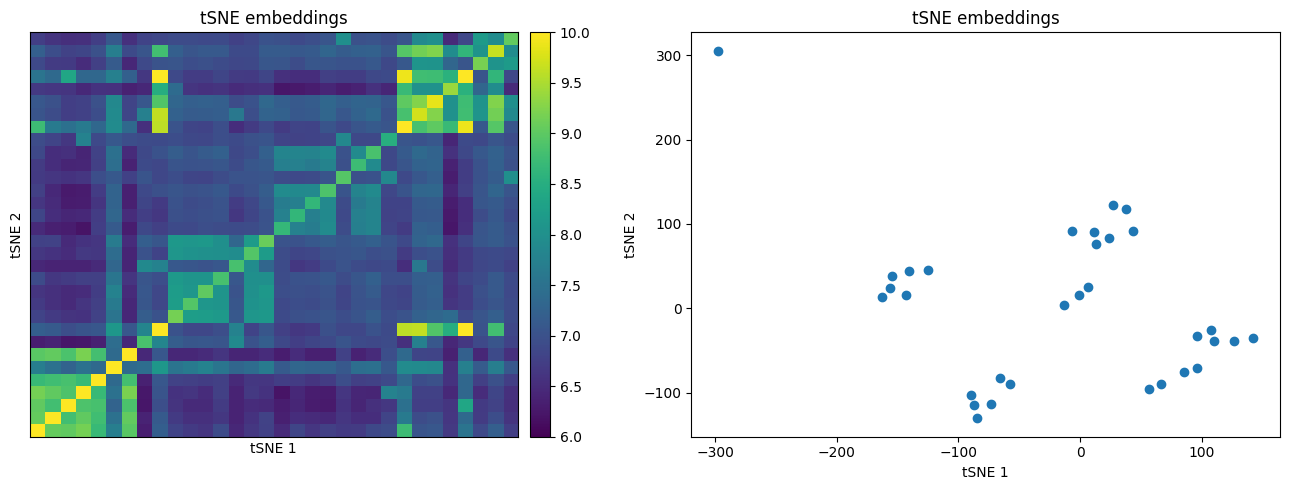

In [25]:
# Visualize
_, axs = plt.subplots(1,2, figsize=(13,5))
im = axs[0].imshow(sub_embeddings @ sub_embeddings.T, vmin=6, vmax=10, origin='lower', aspect='auto')
axs[0].set(xticks=[],yticks=[],xlabel='tSNE 1',ylabel='tSNE 2')
axs[0].title.set_text('tSNE embeddings')
plt.colorbar(im, ax=axs[0], pad=0.02)

axs[1].scatter(tsne_embeddings[:,0],tsne_embeddings[:,1])
axs[1].set(xlabel='tSNE 1',ylabel='tSNE 2', title='tSNE embeddings')

plt.tight_layout()
plt.show()

# DBSCAN

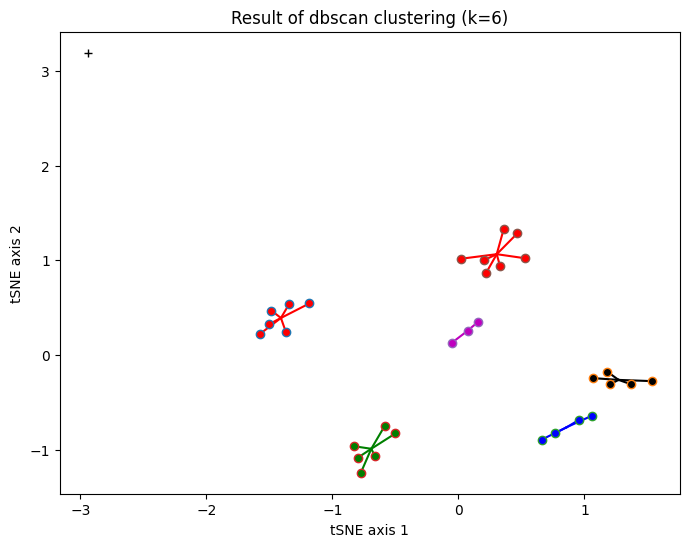

In [26]:
# zscore the tsne_result to use a normalized eps param
tsne_result = (tsne_embeddings-tsne_embeddings.mean()) / tsne_embeddings.std()

## dbscan
clustmodel = DBSCAN(eps=.3,min_samples=3).fit(tsne_result)
groupidx = clustmodel.labels_

# number of clusters
nclust = max(groupidx)+1 # +1 for indexing

# compute cluster centers
cents = np.zeros((nclust,2))
for ci in range(nclust):
  cents[ci,0] = np.mean(tsne_result[groupidx==ci,0])
  cents[ci,1] = np.mean(tsne_result[groupidx==ci,1])

# draw lines from each data point to the centroids of each cluster
plt.figure(figsize=(8,6))
lineColors = 'rkbgm'
for i in range(len(tsne_result)):
  if groupidx[i]==-1:
    plt.plot(tsne_result[i,0],tsne_result[i,1],'k+')
  else:
    plt.plot([ tsne_result[i,0], cents[groupidx[i],0] ],[ tsne_result[i,1], cents[groupidx[i],1] ],lineColors[groupidx[i]%len(lineColors)])


# now draw the raw data in different colors
for i in range(nclust):
  plt.plot(tsne_result[groupidx==i,0],tsne_result[groupidx==i,1],'o',markerfacecolor=lineColors[i%len(lineColors)])

# and now plot the centroid locations
plt.gca().set(xlabel='tSNE axis 1',ylabel='tSNE axis 2',title=f'Result of dbscan clustering (k={nclust})')

plt.show()

In [27]:
for cidx in range(-1,nclust):

  # find all the tokens in this group
  tokensInGroup = np.where(groupidx==cidx)[0]

  # print them out
  if cidx==-1:
    print(f'\nUngrouped tokens:')
  else:
    print(f'\nTokens in group {cidx}:')
  print([ ''.join(emojis[t]) for t in tokensInGroup ])


Ungrouped tokens:
['🦁']

Tokens in group 0:
['😀', '😃', '😄', '😁', '😆', '😂']

Tokens in group 1:
['😅', '💛', '💚', '💙', '💜']

Tokens in group 2:
['🤣', '🖤', '💖', '💗']

Tokens in group 3:
['🐶', '🐱', '🐭', '🐰', '🐻', '🐼']

Tokens in group 4:
['🦊', '🌈', '🌊']

Tokens in group 5:
['❤️', '☀️', '🌤️', '🌧️', '⛈️', '❄️', '🌪️']
